# MACHINE LEARNING   
## Second Assignment   
Roufos Dimitris, 5090   
Charalampos Sapranidis, 4969 (Economics)

In [59]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import torch
import torchvision.models as models
from torch import nn, optim
import torchvision.transforms as transforms

## Part 0: Preprocess Data

In [60]:
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Remove the last fully-connected layer, which is used as the classification layer
ResNet = nn.Sequential(*list(model.children())[:-1])  # The feature extractor we are going to use, we remove the last layer, which categorises images into 1000 classes

ResNet.to(device)

ResNet.eval() # evaluation mode

device

device(type='cpu')

In [61]:
train_dir = 'data/train-images/train'
test_dir = 'data/TEST_images/TEST_images'
index_path = 'data/Test-IDs.csv'

In [62]:
from PIL import Image
import numpy as np

image_size = (224, 224) # we resize images to this resolution, which is expected by ResNet
label_dict = {'pleasant':1, 'unpleasant':0}

X = []
y = []

for label in os.listdir(train_dir):
    class_dir = os.path.join(train_dir, label)  # create OS independent path
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)  # create OS independent path
            try:
                img = Image.open(img_path).convert('RGB')     # RGB with values [0,255]
                img = img.resize(image_size)                         # resize to same size
                img_np = np.array(img)                                                  # shape [H, W, C]
                img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0  # shape [C, H, W]
                img_tensor = img_tensor.unsqueeze(0)
                img_tensor.to(device)
                
                with torch.no_grad():
                    feat = ResNet(img_tensor)                # [1, 2048, 1, 1]
                    feat = torch.flatten(feat, start_dim=1)  # [1, 2048]
                    feat = feat.squeeze(0).cpu().numpy()     # [2048]

                X.append(feat)
                y.append(label_dict[label])
                    
            except Exception as e:
                print(f"Failed to load {img_path}: {e}")



In [63]:
X = np.array(X)
y = np.array(y)

## Part 1. Dimensionality Reduction

### PCA

In [66]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

PCA with M=2, Explained Variance: 0.3051


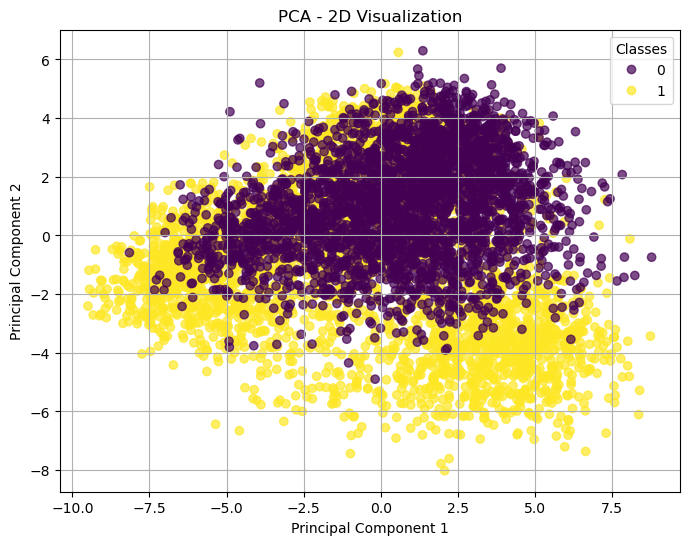

PCA with M=3, Explained Variance: 0.3784


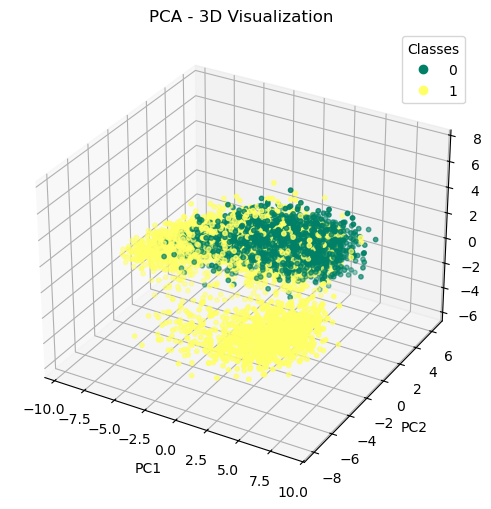

PCA with M=5, Explained Variance: 0.4806
PCA with M=10, Explained Variance: 0.6130
PCA with M=20, Explained Variance: 0.7169


In [68]:
M = [2, 3, 5, 10, 20]
pca_results = []

for m in M:
    pca = PCA(n_components=m)
    X_pca = pca.fit_transform(X)
    pca_results.append(X_pca)

    print(f"PCA with M={m}, Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

    if m == 2:
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
        plt.title('PCA - 2D Visualization')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.legend(*scatter.legend_elements(), title="Classes")
        plt.grid(True)
        plt.show()

    elif m == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, cmap='summer', s=10)
        ax.set_title('PCA - 3D Visualization')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
        plt.show()

### LLE

In [67]:
from sklearn.manifold import LocallyLinearEmbedding

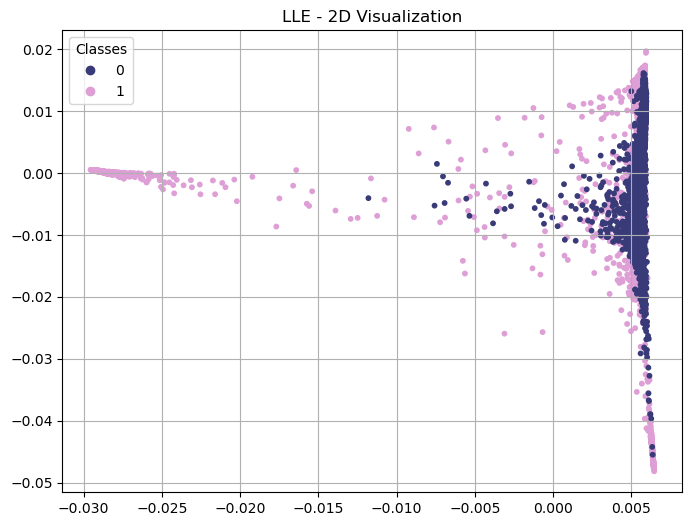

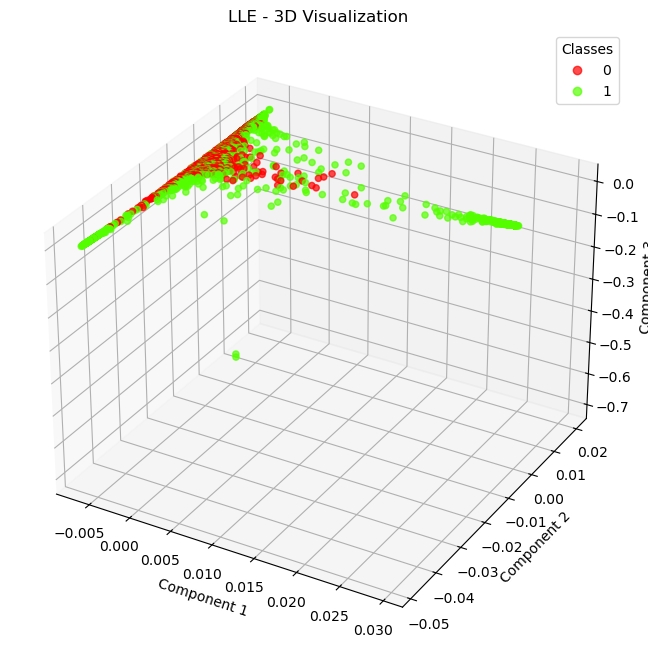

In [69]:
lle_results = []

for m in M:
    lle = LocallyLinearEmbedding(n_neighbors=10, n_components=m)
    X_lle = lle.fit_transform(X)
    lle_results.append(X_lle)

    if m == 2:
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_lle[:, 0], X_lle[:, 1], c=y, cmap='tab20b', s=10)
        plt.title('LLE - 2D Visualization')
        plt.legend(*scatter.legend_elements(), title="Classes")
        plt.grid(True)
        plt.show()

    elif m == 3:
        fig = plt.figure(figsize=(10,8))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(X_lle[:, 0], X_lle[:, 1], X_lle[:, 2], c=y, cmap='prism', alpha=0.7)
        ax.set_title('LLE - 3D Visualization')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        ax.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
        plt.show()

### Autoencoders


In [70]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

#### Step 1: Load Dataset

In [71]:
class TrainDataset(Dataset):
    
    def __init__(self, x, y, transform=None):
        self.x = torch.from_numpy(x)
        self.x = self.x.to(torch.float)
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        sample = [self.x[idx], self.y[idx]]

        if self.transform:
            sample = self.transform(sample)

        return sample

In [72]:
train_dataset = TrainDataset(X,y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#### Step 2: Define Autoencoder

In [73]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=2, input_dim=2048):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded
            

#### Step 3: Train the model

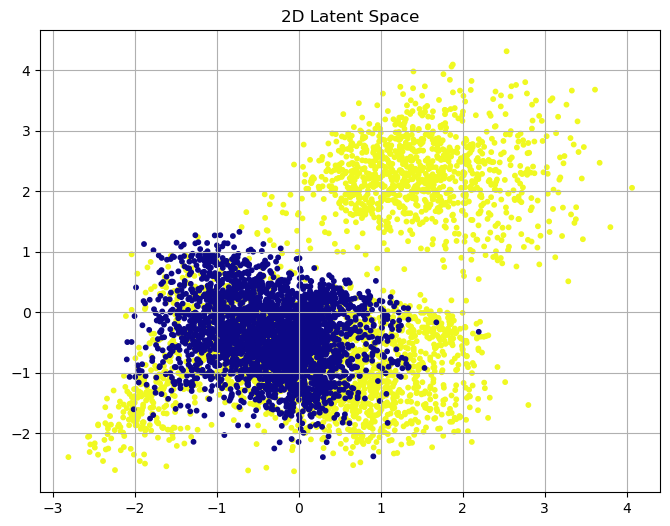

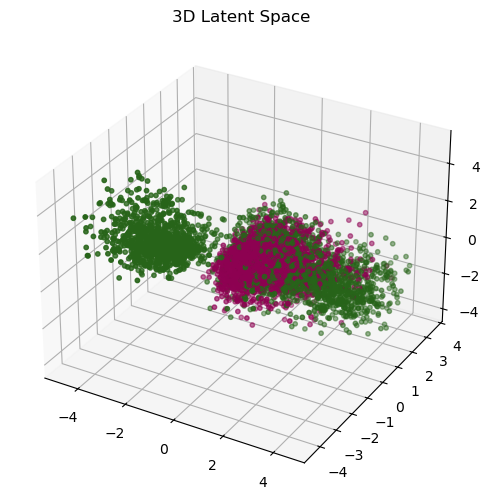

In [76]:
epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(X_tensor), batch_size=64, shuffle=False)

ae_results = []

for m in M:
    model = AutoEncoder(latent_dim=m, input_dim=X_tensor.shape[1])
    model.to(device)
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    losses = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            batch = batch[0].to(device)

            optimizer.zero_grad()
            reconstructed, _ = model(batch)
            loss = loss_function(reconstructed, batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

    # Transform data to latent space
    model.eval()
    with torch.no_grad():
        _, encoded = model(X_tensor.to(device))
        encoded = encoded.cpu().numpy()
        ae_results.append(encoded)

    # Visualize 2D and 3D
    if m == 2:
        plt.figure(figsize=(8, 6))
        plt.scatter(encoded[:, 0], encoded[:, 1], c=y, cmap='plasma', s=10)
        plt.title("2D Latent Space")
        plt.grid(True)
        plt.show()

    elif m == 3:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(encoded[:, 0], encoded[:, 1], encoded[:, 2], c=y, cmap='PiYG', s=10)
        ax.set_title("3D Latent Space")
        plt.show()

## Part 2: Clustering

In [77]:
from sklearn.cluster import KMeans, AgglomerativeClustering

def clustering(Χ, k, method='kmeans'):
    if method == 'kmeans':
        return KMeans(n_clusters=k, random_state=21).fit_predict(Χ)
    elif method == 'agglomerative':
        return AgglomerativeClustering(n_clusters=k, linkage='average').fit_predict(Χ)

## Part 3: Evaluation of Results

In [78]:
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, f1_score
import numpy as np
from scipy.optimize import linear_sum_assignment
import seaborn as sns

def purity_score(y_true, y_pred):
    contingency_matrix = np.zeros((len(set(y_true)), len(set(y_pred))))
    for i, label in enumerate(set(y_true)):
        for j, cluster in enumerate(set(y_pred)):
            contingency_matrix[i, j] = np.sum((np.array(y_true) == label) & (np.array(y_pred) == cluster))
    row_ind, col_ind = linear_sum_assignment(-contingency_matrix)
    return contingency_matrix[row_ind, col_ind].sum() / np.sum(contingency_matrix)

def f_measure(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

def silhouette(X_m, y_pred):
    return silhouette_score(X_m, y_pred)

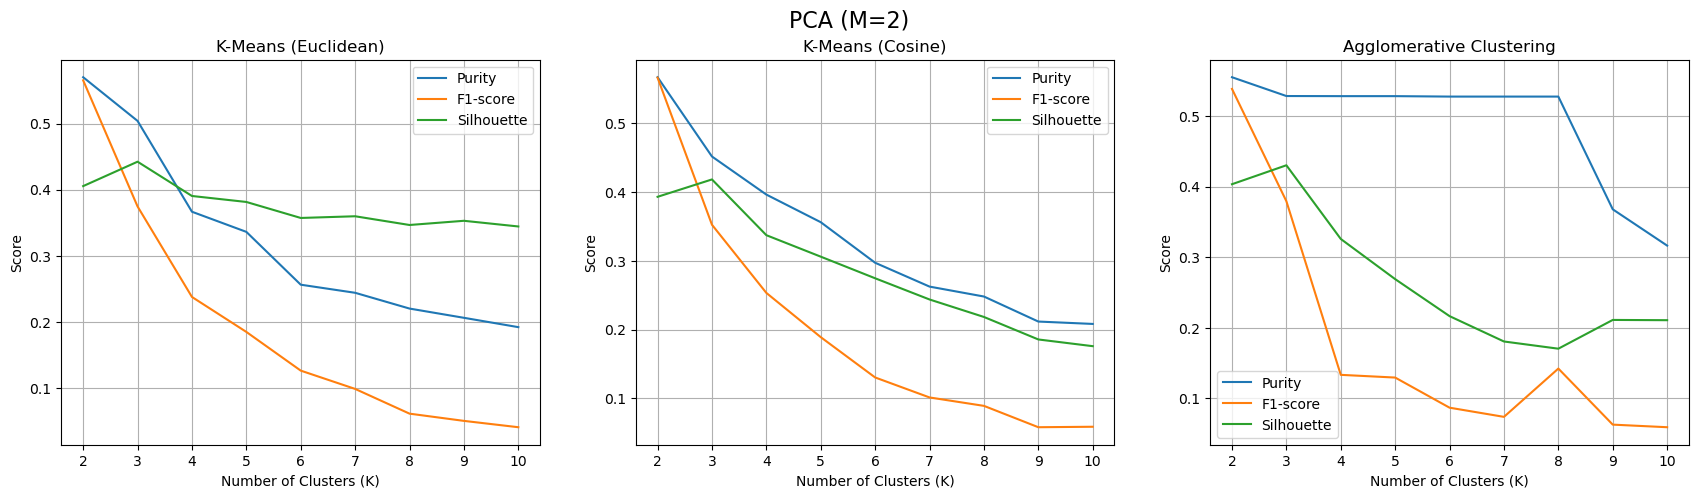

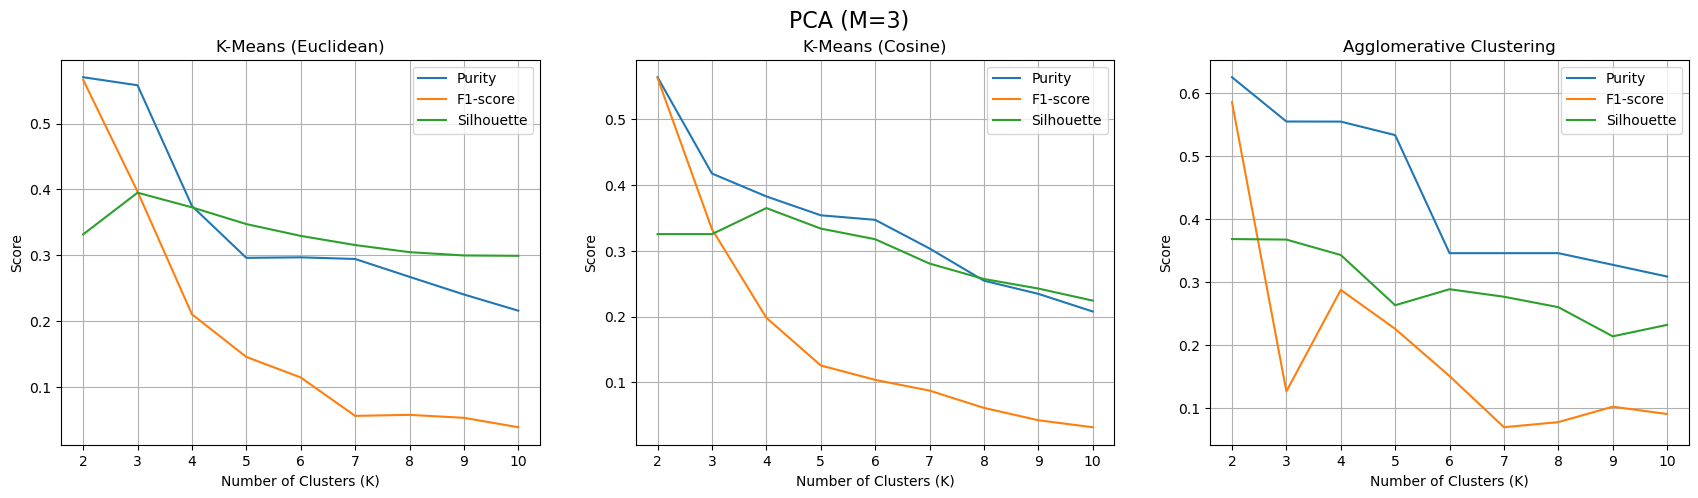

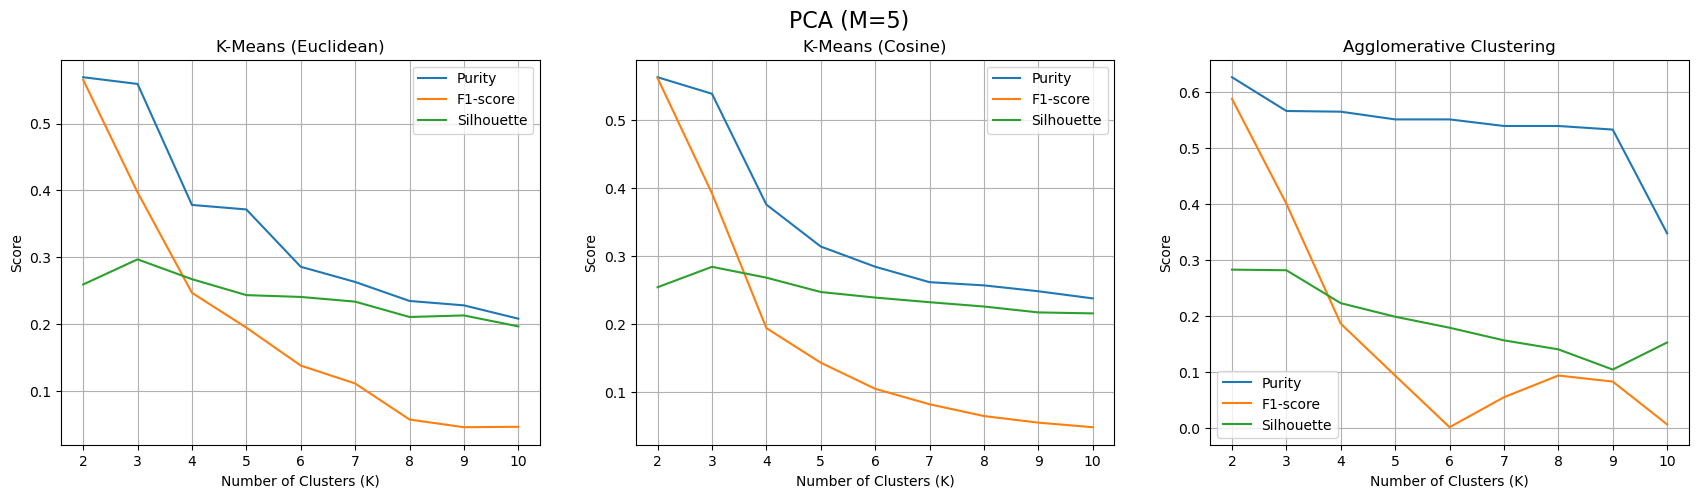

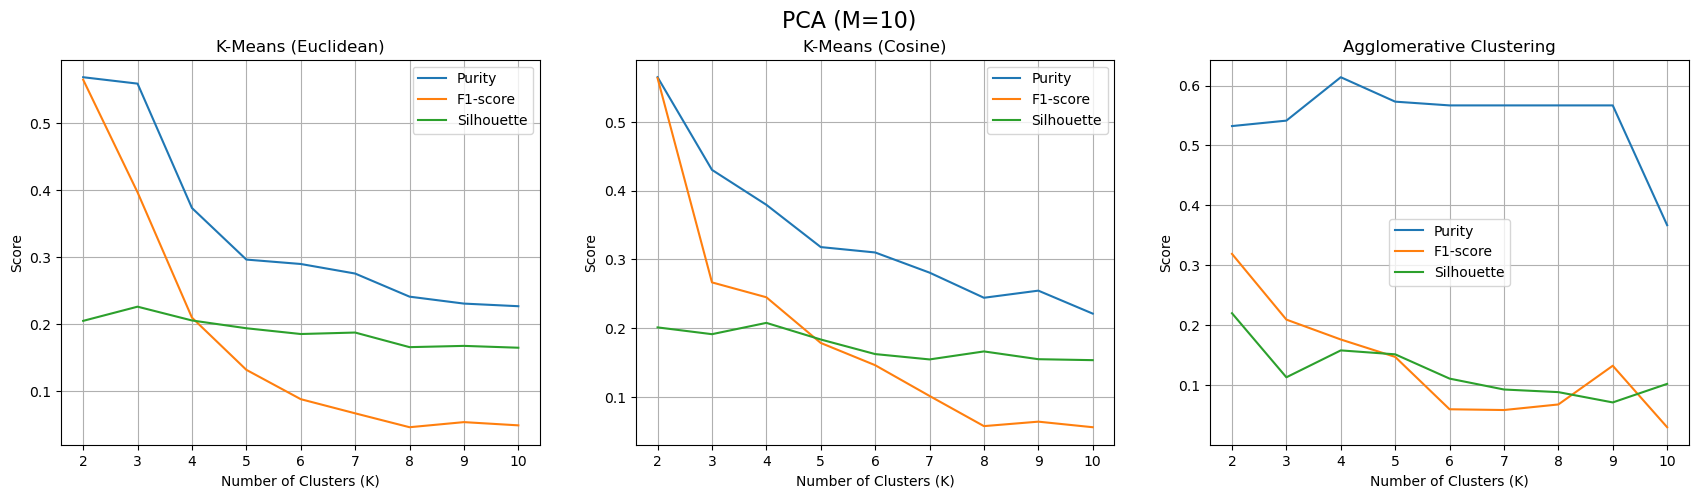

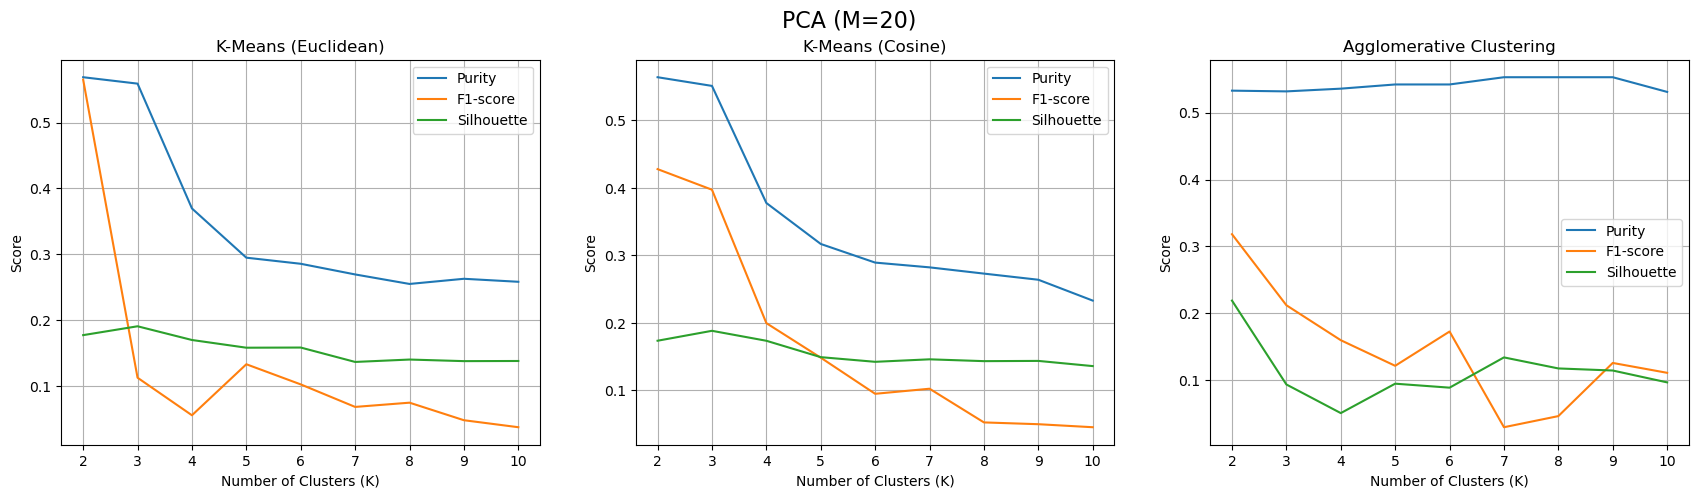

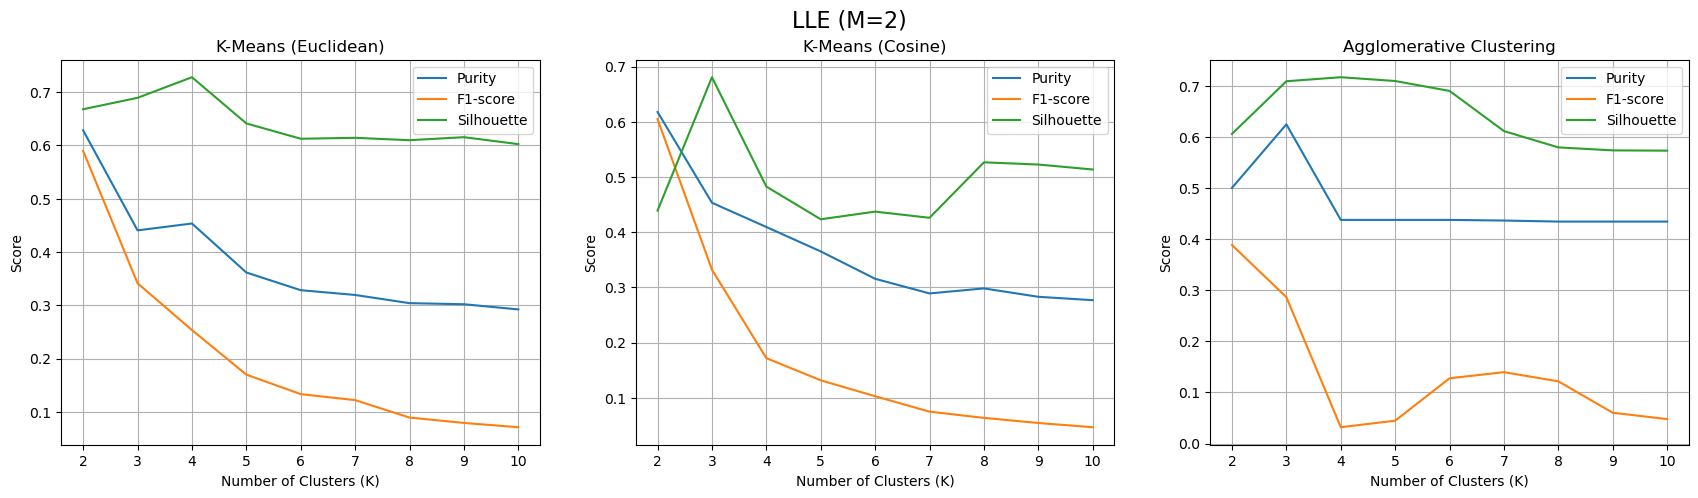

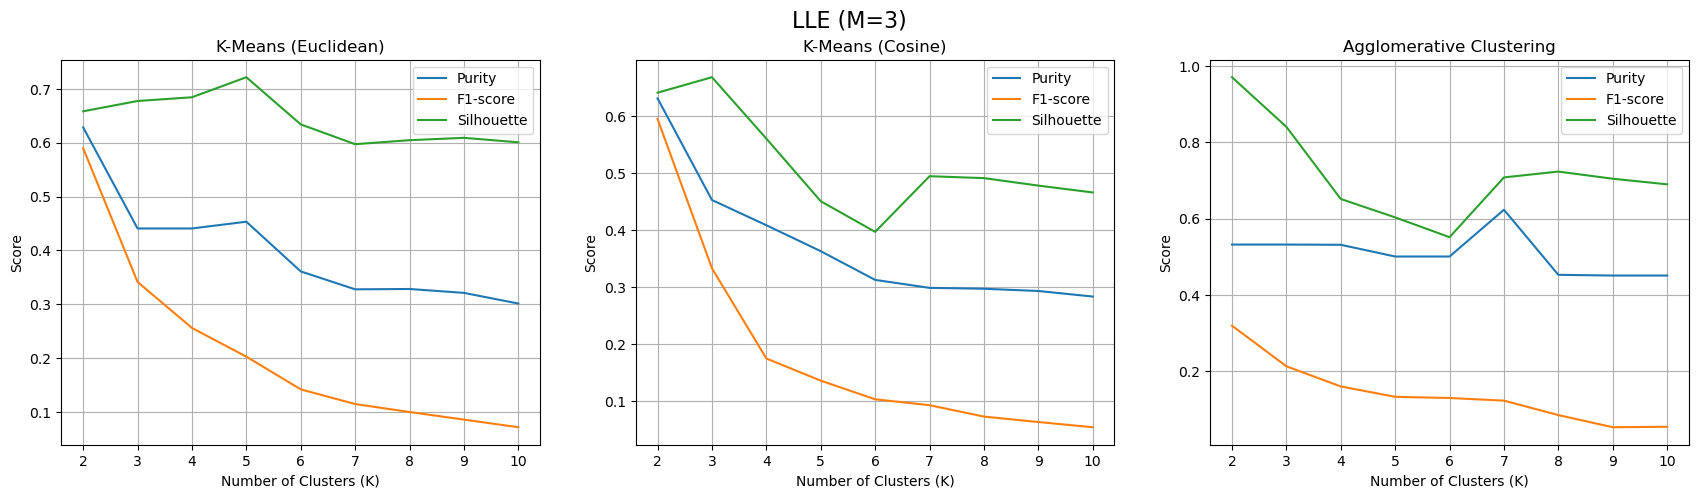

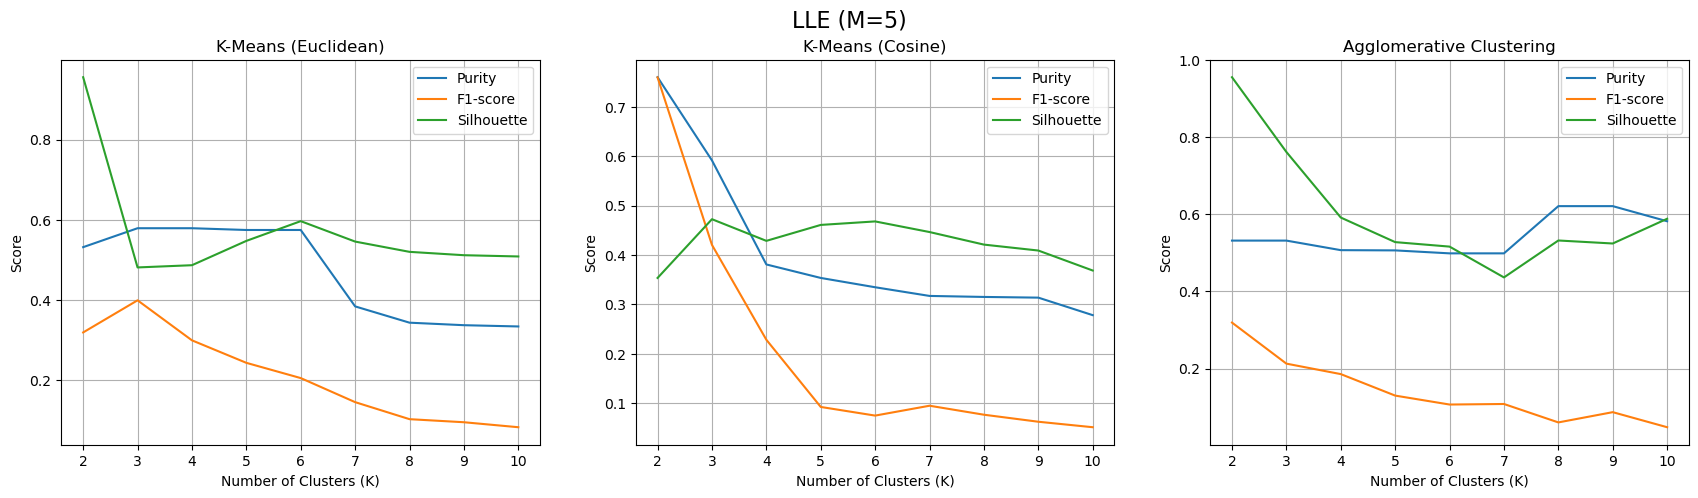

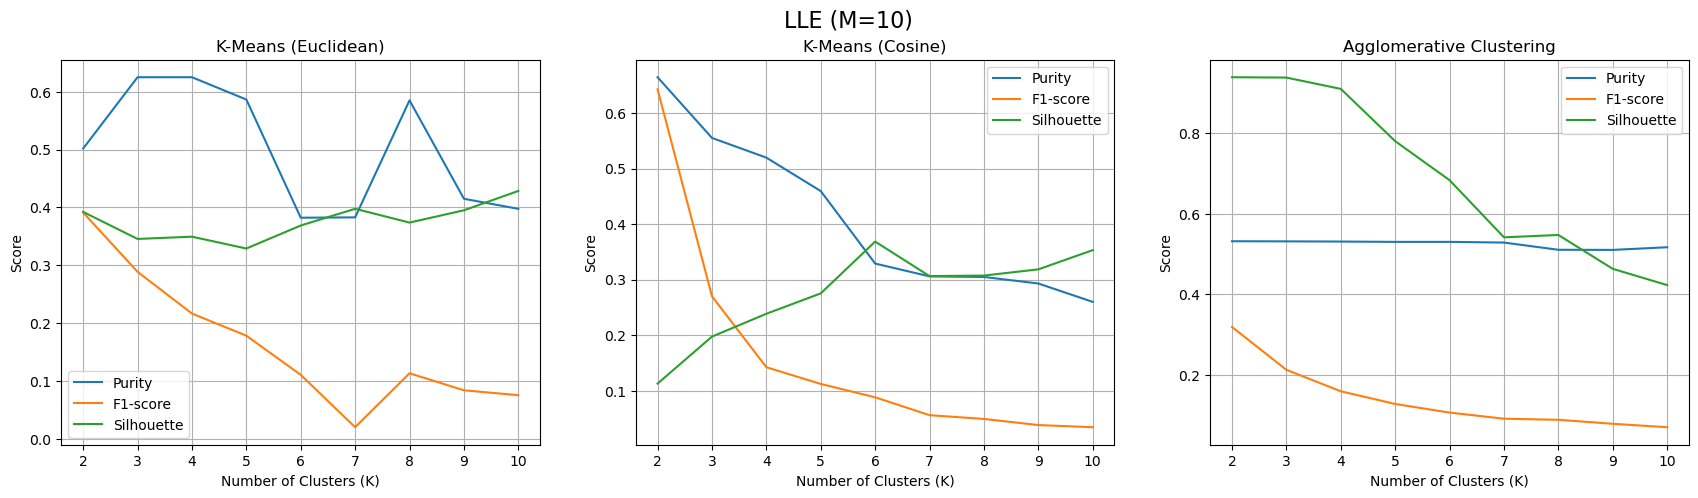

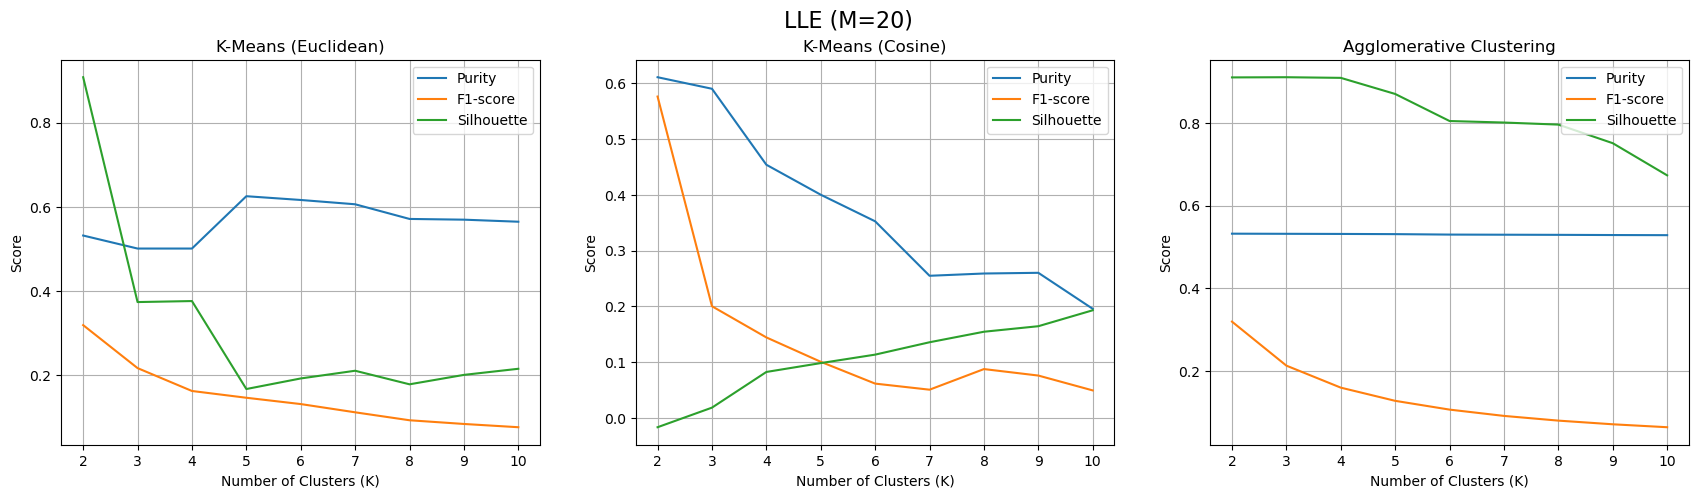

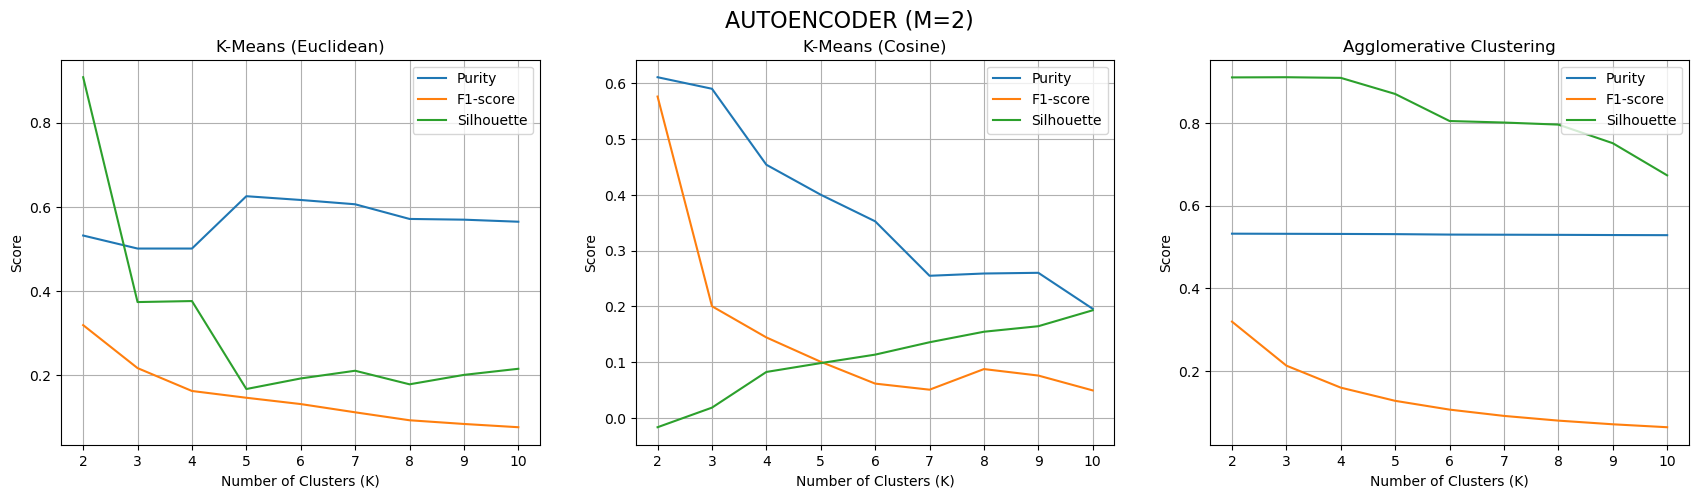

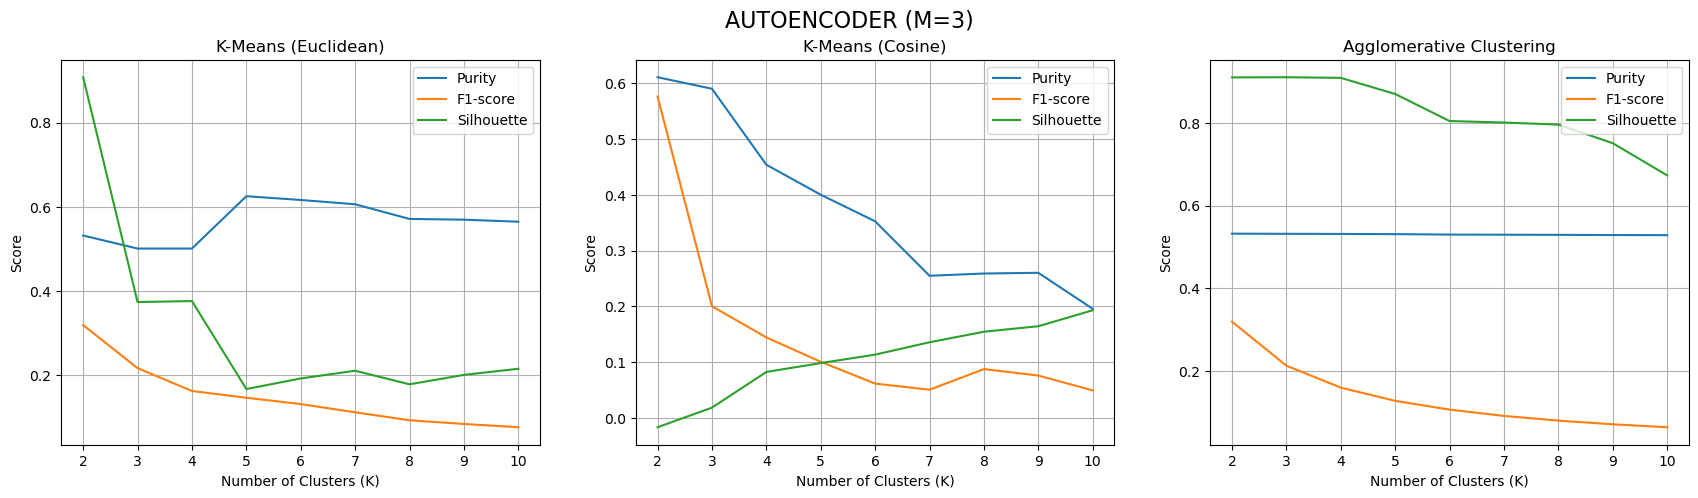

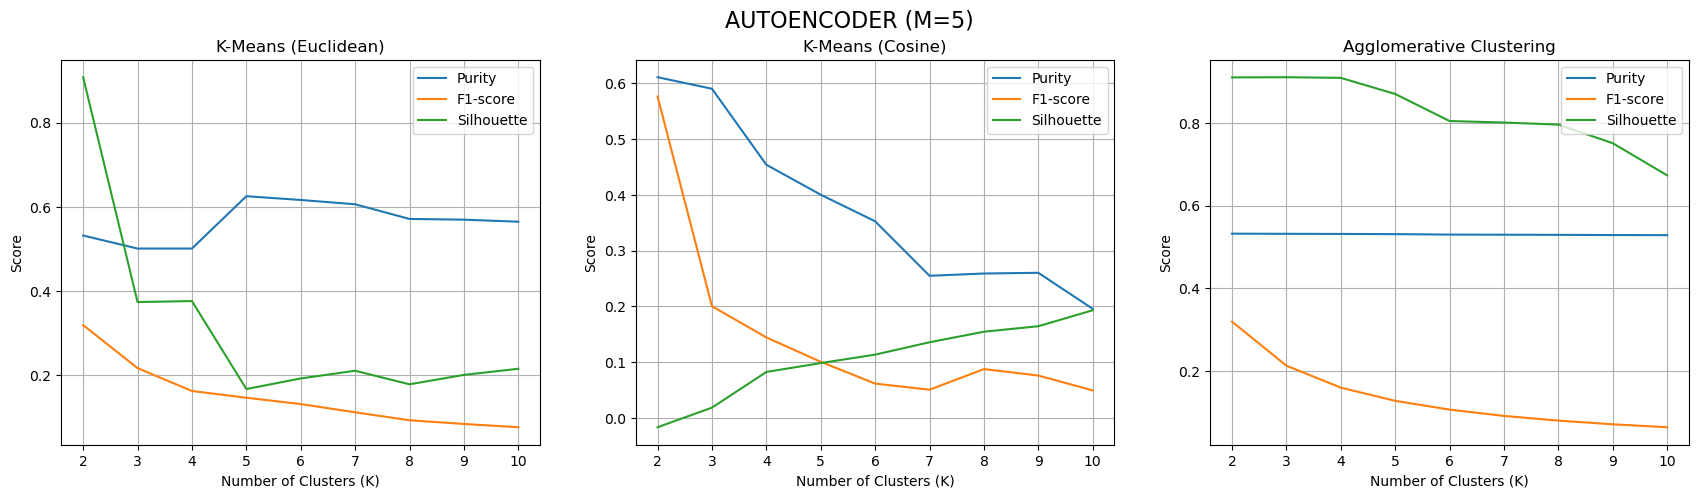

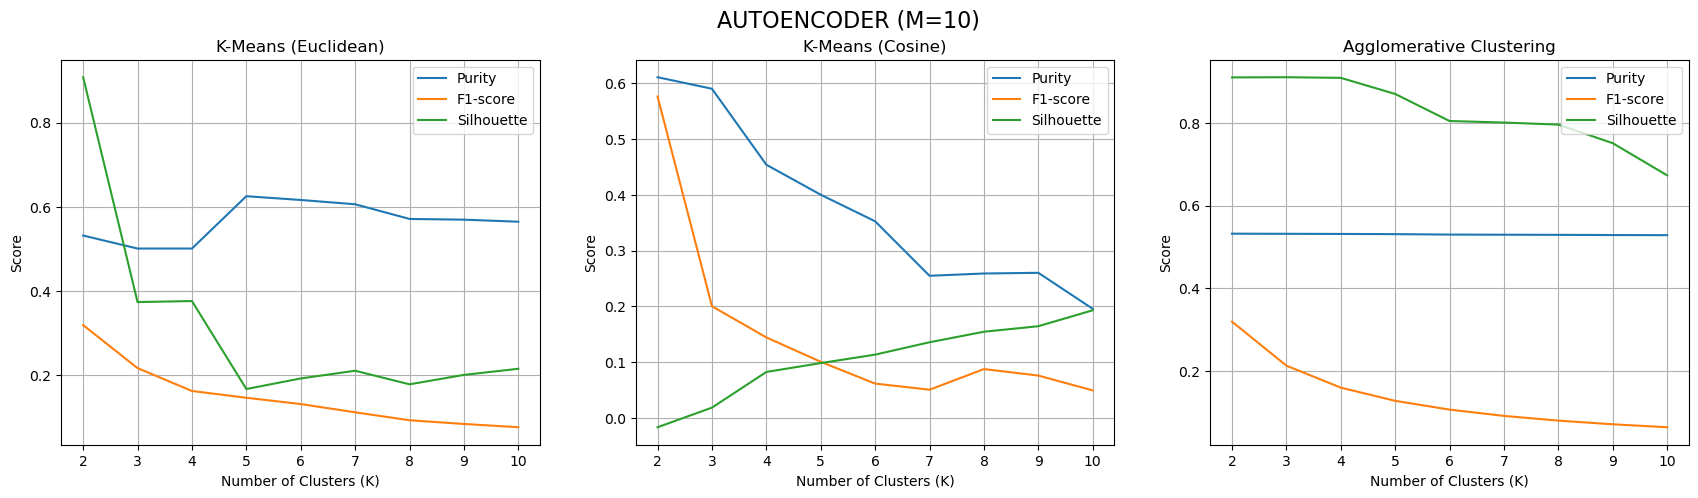

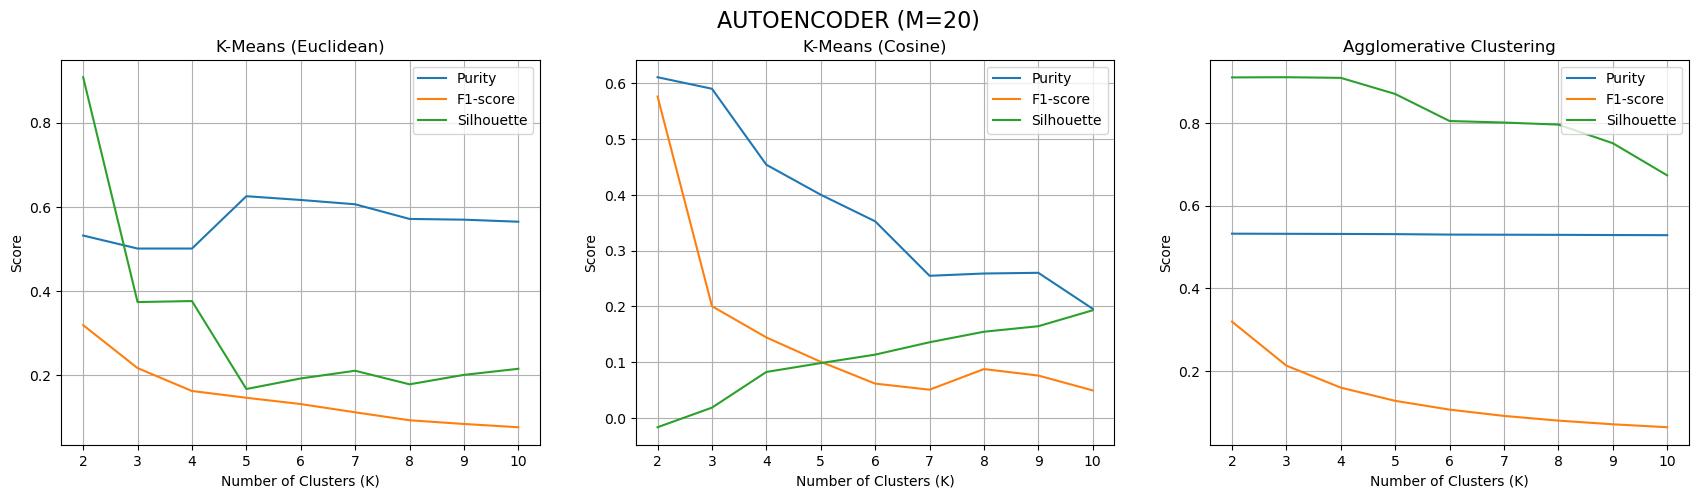

In [79]:
methods = ['pca', 'lle', 'AutoEncoder']
M_values = [2, 3, 5, 10, 20]
cluster_methods = ['kmeans', 'agglomerative']

for method in methods:
    
    for i in range(len(M)):
        
        if method == 'pca':
            X_m = pca_results[i]
        elif method == 'lle':
            X_m = lle_results[i]
        elif method == 'ae':
            X_m = ae_results[i]

        k_results_k = {'k': [], 'purity': [], 'f1': [], 'silhouette': []}
        k_results_cos = {'k': [], 'purity': [], 'f1': [], 'silhouette': []}
        k_results_agglo = {'k': [], 'purity': [], 'f1': [], 'silhouette': []}

        for clustering_method in cluster_methods:
            for k in range(2, 11):

                # K-means
                if clustering_method == 'kmeans':
                    
                    # we need to normalise X to be used like cosine distance, because sklearn doeas not support it directly
                    y_pred_cos = clustering(normalize(X_m), k, clustering_method)
                    purity = purity_score(y, y_pred_cos)
                    f1 = f_measure(y, y_pred_cos)
                    sil = silhouette(X_m, y_pred_cos)

                    k_results_cos['k'].append(k)
                    k_results_cos['purity'].append(purity)
                    k_results_cos['f1'].append(f1)
                    k_results_cos['silhouette'].append(sil)
                
                    # This is using the (default) Euclidean distance
                    y_pred = clustering(X_m, k, clustering_method)
                    purity = purity_score(y, y_pred)
                    f1 = f_measure(y, y_pred)
                    sil = silhouette(X_m, y_pred)
    
                    k_results_k['k'].append(k)
                    k_results_k['purity'].append(purity)
                    k_results_k['f1'].append(f1)
                    k_results_k['silhouette'].append(sil)

                # Agglomerative Clustering
                else:
                    y_pred = clustering(X_m, k, clustering_method)
                    purity = purity_score(y, y_pred)
                    f1 = f_measure(y, y_pred)
                    sil = silhouette(X_m, y_pred)
    
                    k_results_agglo['k'].append(k)
                    k_results_agglo['purity'].append(purity)
                    k_results_agglo['f1'].append(f1)
                    k_results_agglo['silhouette'].append(sil)

        # Create the subplot grid
        fig, axes = plt.subplots(1, 3, figsize=(21, 5))
        fig.suptitle(f'{method.upper()} (M={M[i]})', fontsize=16)
        
        # 1. KMeans (Euclidean)
        ax = axes[0]
        sns.lineplot(x=k_results_k['k'], y=k_results_k['purity'], label='Purity', ax=ax)
        sns.lineplot(x=k_results_k['k'], y=k_results_k['f1'], label='F1-score', ax=ax)
        sns.lineplot(x=k_results_k['k'], y=k_results_k['silhouette'], label='Silhouette', ax=ax)
        ax.set_title('K-Means (Euclidean)')
        ax.set_xlabel('Number of Clusters (K)')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)
        
        # 2. KMeans (Cosine)
        ax = axes[1]
        sns.lineplot(x=k_results_cos['k'], y=k_results_cos['purity'], label='Purity', ax=ax)
        sns.lineplot(x=k_results_cos['k'], y=k_results_cos['f1'], label='F1-score', ax=ax)
        sns.lineplot(x=k_results_cos['k'], y=k_results_cos['silhouette'], label='Silhouette', ax=ax)
        ax.set_title('K-Means (Cosine)')
        ax.set_xlabel('Number of Clusters (K)')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)
        
        # 3. Agglomerative
        ax = axes[2]
        sns.lineplot(x=k_results_agglo['k'], y=k_results_agglo['purity'], label='Purity', ax=ax)
        sns.lineplot(x=k_results_agglo['k'], y=k_results_agglo['f1'], label='F1-score', ax=ax)
        sns.lineplot(x=k_results_agglo['k'], y=k_results_agglo['silhouette'], label='Silhouette', ax=ax)
        ax.set_title('Agglomerative Clustering')
        ax.set_xlabel('Number of Clusters (K)')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)